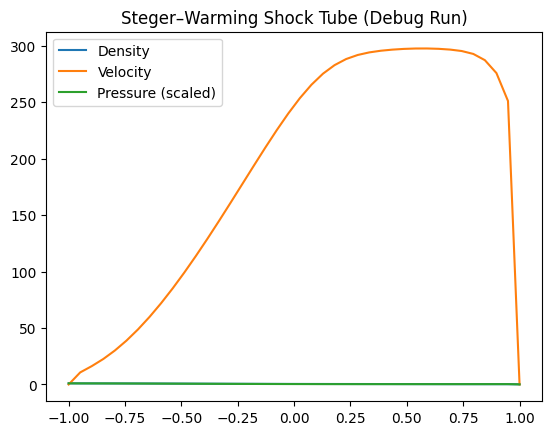

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 1.4

# -----------------------------
# Grid
# -----------------------------
N = 40   # small for debugging
x = np.linspace(-1, 1, N)
dx = x[1] - x[0]

# -----------------------------
# Initial condition (shock tube)
# -----------------------------
U = np.zeros((N, 3))  # [rho, rho*u, rho*E]

for i in range(N):
    if x[i] < 0:
        rho, u, p = 1.0, 0.0, 100000.0
    else:
        rho, u, p = 0.125, 0.0, 10000.0

    E = p/((gamma-1)*rho) + 0.5*u**2
    U[i] = [rho, rho*u, rho*E]

# -----------------------------
# Helper functions
# -----------------------------s
def primitive(U):
    rho = U[0]
    u   = U[1]/rho
    E   = U[2]/rho
    p   = (gamma-1)*(rho*E - 0.5*rho*u**2)
    a   = np.sqrt(gamma*p/rho)
    return rho, u, p, a

def flux_from_lambdas(rho, u, a, l1, l2, l3):
    g = gamma
    
    F1 = 2*(g-1)*l1 + l2 + l3
    
    F2 = 2*(g-1)*l1*u + l2*(u+a) + l3*(u-a)
    
    F3 = ((g-1)*l1*u**2
          + 0.5*l2*(u+a)**2
          + 0.5*l3*(u-a)**2
          + (3-g)/(2*(g-1))*(l2+l3)*a**2)
    
    return (rho/(2*g)) * np.array([F1, F2, F3])

def flux_plus(U):
    rho, u, p, a = primitive(U)

    l1 = max(u, 0)
    l2 = max(u + a, 0)
    l3 = max(u - a, 0)

    return flux_from_lambdas(rho, u, a, l1, l2, l3)

def flux_minus(U):
    rho, u, p, a = primitive(U)

    l1 = min(u, 0)
    l2 = min(u + a, 0)
    l3 = min(u - a, 0)

    return flux_from_lambdas(rho, u, a, l1, l2, l3)

# -----------------------------
# Time stepping
# -----------------------------
CFL = 0.4
t = 0.0
t_end = 0.002  # short run for testing

while t < t_end:
    
    # Compute max wave speed
    max_speed = 0
    for i in range(N):
        rho, u, p, a = primitive(U[i])
        max_speed = max(max_speed, abs(u) + a)

    dt = CFL * dx / max_speed
    if t + dt > t_end:
        dt = t_end - t

    # Compute interface fluxes
    F_half = np.zeros((N-1, 3))

    for i in range(N-1):
        UL = U[i]
        UR = U[i+1]

        F_half[i] = flux_plus(UL) + flux_minus(UR)

    # Update solution
    U_new = U.copy()

    for i in range(1, N-1):
        U_new[i] = U[i] - (dt/dx)*(F_half[i] - F_half[i-1])

    U = U_new
    t += dt

# -----------------------------
# Plot results
# -----------------------------
rho = U[:,0]
u   = U[:,1]/rho
p   = (gamma-1)*(U[:,2] - 0.5*rho*u**2)

plt.figure()
plt.plot(x, rho, label="Density")
plt.plot(x, u, label="Velocity")
plt.plot(x, p/100000, label="Pressure (scaled)")
plt.legend()
plt.title("Steger–Warming Shock Tube (Debug Run)")
plt.show()

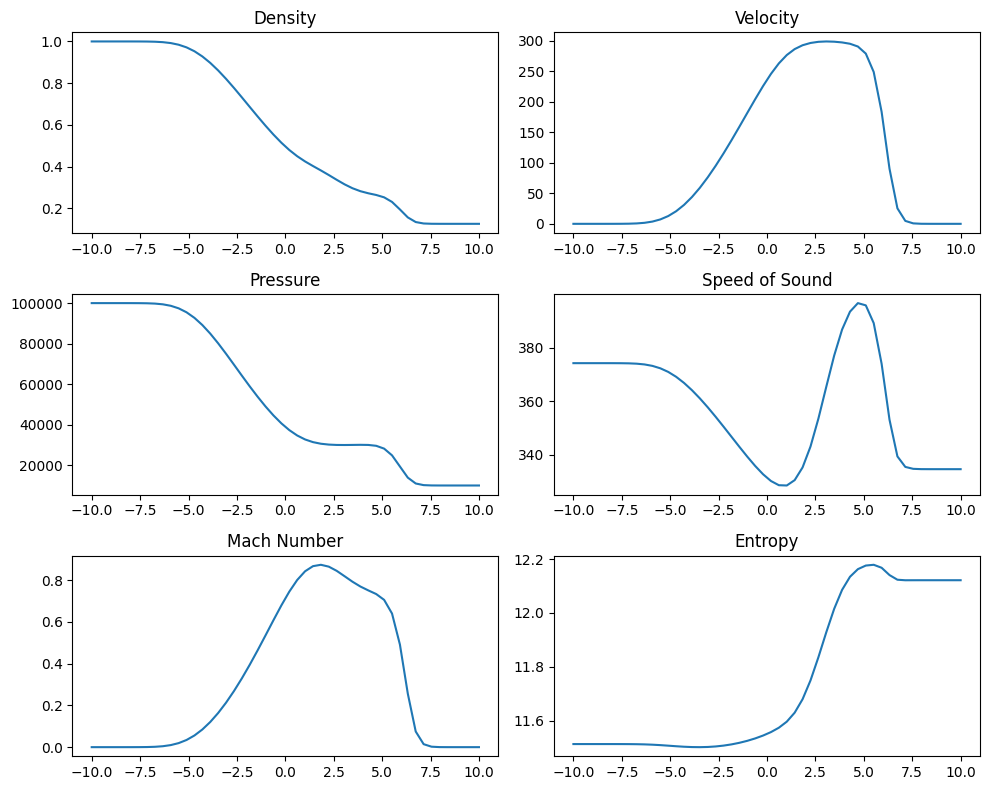

In [2]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 1.4

# -----------------------------
# Grid & numerical parameters
# -----------------------------
N = 50
x = np.linspace(-10, 10, N)
dx = 20.0 / N

CFL = 0.4
dt = 4.276e-4   # given
t_end = 0.01

# -----------------------------
# Initialize conserved variables
# U = [rho, rho*u, rho*E]
# -----------------------------
U = np.zeros((N, 3))

for i in range(N):
    if x[i] < 0:
        rho, u, p = 1.0, 0.0, 100000.0
    else:
        rho, u, p = 0.125, 0.0, 10000.0

    E = p/((gamma-1)*rho) + 0.5*u**2
    U[i] = [rho, rho*u, rho*E]

# -----------------------------
# Helper functions
# -----------------------------
def primitive(U):
    rho = U[0]
    u   = U[1] / rho
    E   = U[2] / rho
    p   = (gamma-1)*(rho*E - 0.5*rho*u**2)
    a   = np.sqrt(gamma*p/rho)
    return rho, u, p, a

def flux_from_lambdas(rho, u, a, l1, l2, l3):
    g = gamma
    
    F1 = 2*(g-1)*l1 + l2 + l3
    
    F2 = 2*(g-1)*l1*u + l2*(u+a) + l3*(u-a)
    
    F3 = ((g-1)*l1*u**2
          + 0.5*l2*(u+a)**2
          + 0.5*l3*(u-a)**2
          + (3-g)/(2*(g-1))*(l2+l3)*a**2)
    
    return (rho/(2*g)) * np.array([F1, F2, F3])

def flux_plus(U):
    rho, u, p, a = primitive(U)

    l1 = max(u, 0)
    l2 = max(u + a, 0)
    l3 = max(u - a, 0)

    return flux_from_lambdas(rho, u, a, l1, l2, l3)

def flux_minus(U):
    rho, u, p, a = primitive(U)

    l1 = min(u, 0)
    l2 = min(u + a, 0)
    l3 = min(u - a, 0)

    return flux_from_lambdas(rho, u, a, l1, l2, l3)

# -----------------------------
# Time integration
# -----------------------------
t = 0.0

while t < t_end:
    
    F_half = np.zeros((N-1, 3))

    # Compute interface fluxes
    for i in range(N-1):
        UL = U[i]
        UR = U[i+1]
        F_half[i] = flux_plus(UL) + flux_minus(UR)

    # Update solution
    U_new = U.copy()
    for i in range(1, N-1):
        U_new[i] = U[i] - (dt/dx)*(F_half[i] - F_half[i-1])

    U = U_new
    t += dt

# -----------------------------
# Post-processing
# -----------------------------
rho = np.zeros(N)
u   = np.zeros(N)
p   = np.zeros(N)
a   = np.zeros(N)
M   = np.zeros(N)
s   = np.zeros(N)

for i in range(N):
    rho[i], u[i], p[i], a[i] = primitive(U[i])
    M[i] = u[i] / a[i]
    
    # Entropy (up to constant): s = ln(p / rho^gamma)
    s[i] = np.log(p[i] / rho[i]**gamma)

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(10,8))

plt.subplot(3,2,1)
plt.plot(x, rho)
plt.title("Density")

plt.subplot(3,2,2)
plt.plot(x, u)
plt.title("Velocity")

plt.subplot(3,2,3)
plt.plot(x, p)
plt.title("Pressure")

plt.subplot(3,2,4)
plt.plot(x, a)
plt.title("Speed of Sound")

plt.subplot(3,2,5)
plt.plot(x, M)
plt.title("Mach Number")

plt.subplot(3,2,6)
plt.plot(x, s)
plt.title("Entropy")

plt.tight_layout()
plt.show()